# Project 3: Supply Chain Analytics - Demand Forecasting & Anomaly Detection

## Week 2

### Member 2: Visualization, Validation & Business Analysis

#### Objective

- Load processed anomaly detection datasets.
- Merge anomaly labels into a unified dataset.
- Verify anomaly columns.
- Export the final dataset for visualization and business analysis.

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## Step 2: Load Member Datasets

In [2]:
zscore_df = pd.read_excel("z-score_retail_storeinventory.xlsx")

merged_df = pd.read_csv("final_merged_dataset.csv")

## Step 3: Verify Dataset Structure

In [3]:
print("Z-Score Dataset")

print(zscore_df.shape)

print(zscore_df.columns)

print()

print("Merged Dataset")

print(merged_df.shape)

print(merged_df.columns)

Z-Score Dataset
(73100, 16)
Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'Anomaly'],
      dtype='object')

Merged Dataset
(73100, 17)
Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'IQR_Anomaly', 'IsolationForest'],
      dtype='object')


## Step 4: Merge Z-Score Anomaly Column

In [4]:
merged_df["ZScore_Anomaly"] = zscore_df["Anomaly"]

## Step 5: Verify Anomaly Columns

In [5]:
merged_df[
    [
        "ZScore_Anomaly",
        "IQR_Anomaly",
        "IsolationForest"
    ]
].head()

,ZScore_Anomaly,IQR_Anomaly,IsolationForest
0,False,0,0
1,False,0,0
2,False,0,0
3,False,0,0
4,False,0,0


## Step 6: Export Final Dataset

In [6]:
merged_df.to_excel(
    "final_anomaly_dataset.xlsx",
    index=False
)

print("Final anomaly dataset exported successfully.")

Final anomaly dataset exported successfully.


### Observation

Successfully merged anomaly labels from Z-Score, IQR, and Isolation Forest into a unified dataset. The exported dataset will be used for visualization, comparison, and business validation in the upcoming analysis steps.

## Step 7: Visualize Z-Score Anomalies

In this step, anomalies detected using the Z-Score method are visualized on a time-series graph. The visualization highlights statistically unusual sales observations that deviate significantly from the normal sales pattern.

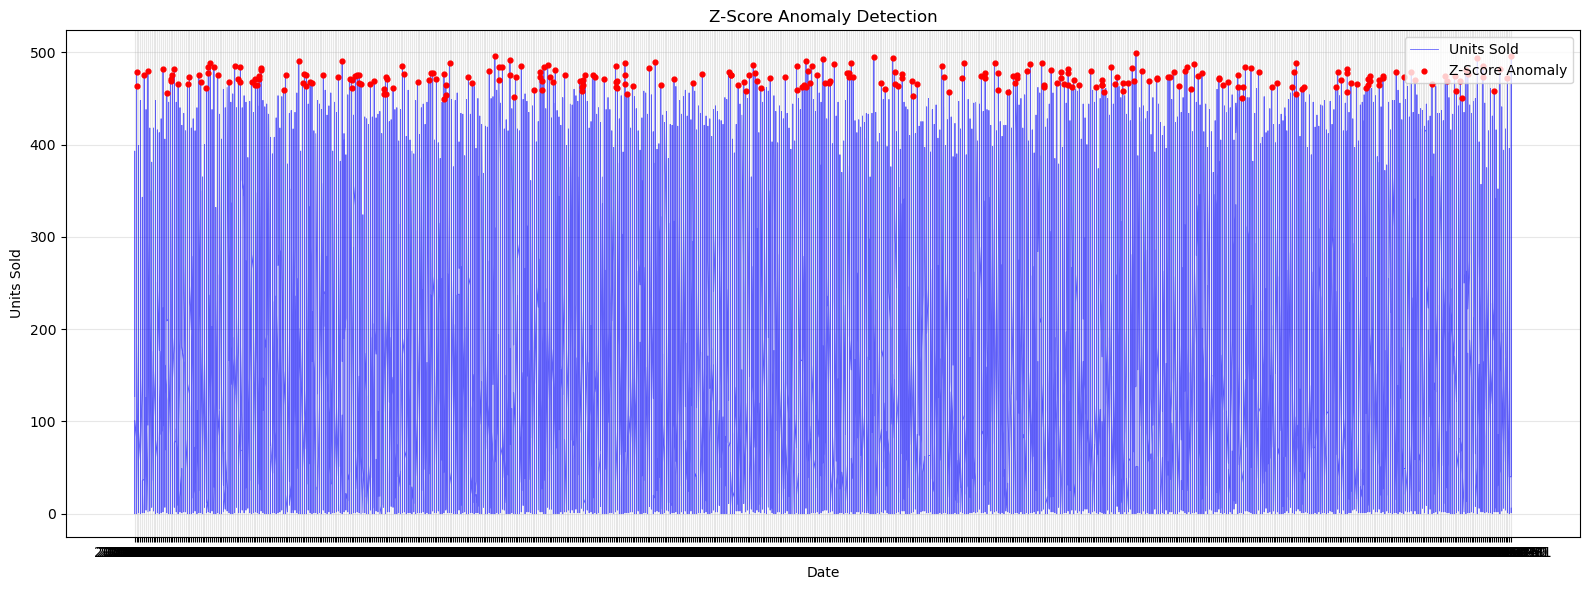

In [7]:
plt.figure(figsize=(16,6))

plt.plot(
    merged_df["Date"],
    merged_df["Units Sold"],
    color="blue",
    linewidth=0.6,
    alpha=0.6,
    label="Units Sold"
)

plt.scatter(
    merged_df.loc[
        merged_df["ZScore_Anomaly"]==True,
        "Date"
    ],
    merged_df.loc[
        merged_df["ZScore_Anomaly"]==True,
        "Units Sold"
    ],
    color="red",
    s=12,
    label="Z-Score Anomaly",
    zorder=3
)

plt.title("Z-Score Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

The Z-Score visualization highlights statistically unusual sales observations. Red points indicate sales values that significantly deviate from the normal sales pattern and may represent abnormal demand, inventory issues, or unexpected business events.

## Step 8: Visualize IQR Anomalies

In this step, anomalies detected using the Interquartile Range (IQR) method are visualized on a time-series graph. The visualization highlights observations that fall outside the expected interquartile range and may indicate unusual sales behavior.

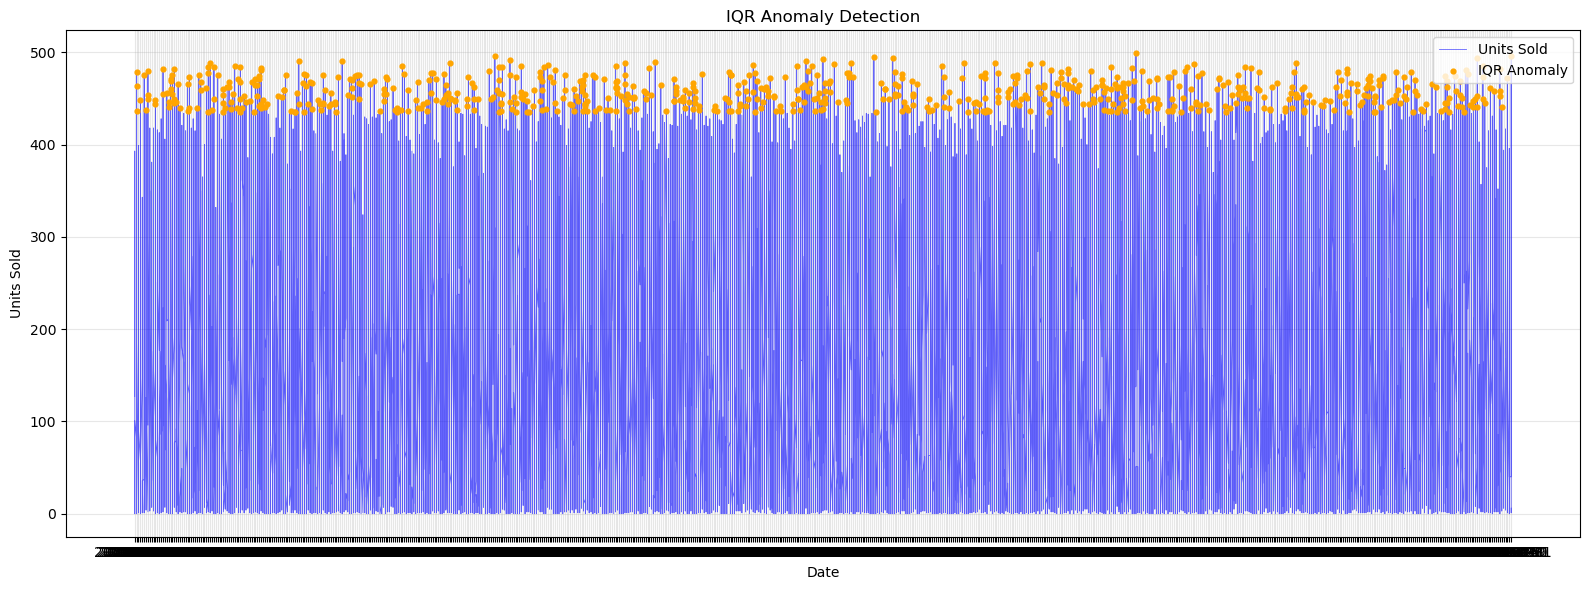

In [8]:
plt.figure(figsize=(16,6))

plt.plot(
    merged_df["Date"],
    merged_df["Units Sold"],
    color="blue",
    linewidth=0.6,
    alpha=0.6,
    label="Units Sold"
)

plt.scatter(
    merged_df.loc[
        merged_df["IQR_Anomaly"]==True,
        "Date"
    ],
    merged_df.loc[
        merged_df["IQR_Anomaly"]==True,
        "Units Sold"
    ],
    color="orange",
    s=12,
    label="IQR Anomaly",
    zorder=3
)

plt.title("IQR Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

The IQR visualization identifies observations outside the expected interquartile range. Orange points represent potential anomalies that may indicate unusual sales behavior caused by demand fluctuations, inventory issues, or operational events.